# 🩺 Project: Stroke Risk Intelligence Analysis
**Subtítulo:** Estrategia de Salud Basada en Datos y Machine Learning para la Prevención Vascular  
**Autor:** Dra. Dalina Gaxiola  
**Rol:** Clinical Data Scientist & Medical Strategy  

---

## 📑 Resumen Ejecutivo y Roadmap
El Accidente Cerebrovascular (ACV) es una de las principales causas de discapacidad y mortalidad global. Este proyecto no es solo un ejercicio de programación, sino una herramienta de **Inteligencia en Salud** diseñada para identificar perfiles de riesgo mediante el análisis de variables clínicas y demográficas.

Nuestra metodología se basa en el rigor científico, buscando no solo precisión técnica, sino utilidad clínica y alineación con los estándares modernos de **Real World Evidence (RWE)**.

### Estructura del Notebook:
1. **Fase 1: Curación y Calidad de Datos:** Limpieza profunda e imputación de valores faltantes con lógica médica.
2. **Fase 2: Análisis Estadístico e Inferencial:** Validación de factores de riesgo mediante pruebas de significancia ($p$-values).
3. **Fase 3: Ingeniería de Características (Feature Engineering):** Creación de scores de comorbilidad para potenciar la capacidad predictiva.
4. **Fase 4: Modelado con Foco en Seguridad:** Entrenamiento de algoritmos priorizando la sensibilidad (detección oportuna).
5. **Fase 5: Visualización Estratégica:** Desarrollo de dashboards interactivos para la toma de decisiones médicas.

---

## Fase 1: Curación y Calidad de Datos
En medicina, un dato erróneo puede llevar a un diagnóstico equivocado. Iniciamos cargando la información y realizando una auditoría de calidad, enfocándonos especialmente en el **Índice de Masa Corporal (IMC)**. Dado que el IMC es un factor crítico, aplicamos una técnica de "imputación por grupo", estimando los valores faltantes según el género y rango de edad del paciente, evitando así el sesgo de un promedio general.

In [ ]:
import pandas as pd
import numpy as np

# Paso 1: Carga del dataset con la ruta específica de tu entorno en Colab
# Asegúrate de que el archivo aparezca con este nombre exacto en la carpeta lateral
file_path = '/content/healthcare-dataset-stroke-data 2.csv'
df = pd.read_csv(file_path)

# Paso 2: Eliminación de datos administrativos
# Removemos el 'id' ya que no posee relevancia fisiológica para el riesgo de stroke.
df.drop('id', axis=1, inplace=True)

# Paso 3: Curación del IMC (BMI) con Criterio Clínico
# El IMC varía fisiológicamente con la edad. Creamos bins (grupos) para una estimación más precisa.
df['age_group'] = pd.cut(df['age'], bins=[0, 18, 40, 65, 100], labels=['Menor', 'Adulto Joven', 'Adulto', 'Senior'])

# Imputamos valores nulos del BMI usando la mediana del grupo de edad y género correspondiente.
df['bmi'] = df['bmi'].fillna(df.groupby(['gender', 'age_group'])['bmi'].transform('median'))

# Paso 4: Limpieza de categorías marginales
# Eliminamos registros con género 'Other' para garantizar la robustez de las futuras pruebas estadísticas.
df = df[df['gender'] != 'Other']

# Reporte de Calidad de Datos
print("--- REPORTE DE CALIDAD FINALIZADO ---")
print(f"Total de registros: {df.shape[0]}")
print(f"Valores nulos detectados:\n{df.isnull().sum()}")
print("\nPrimeros 5 registros curados:")
df.head()

--- REPORTE DE CALIDAD FINALIZADO ---
Total de registros: 5109
Valores nulos detectados:
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
age_group            0
dtype: int64

Primeros 5 registros curados:


/tmp/ipykernel_32883/4223115865.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['bmi'] = df['bmi'].fillna(df.groupby(['gender', 'age_group'])['bmi'].transform('median'))


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_group
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,Senior
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,29.7,never smoked,1,Adulto
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,Senior
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,Adulto
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,Senior


### ✅ Conclusión de la Fase 1: Calidad y Curación de Datos
Tras la ejecución del proceso de limpieza, hemos transformado un conjunto de datos crudo en una base sólida y confiable para el análisis. Los hitos alcanzados en esta etapa son:

1. **Integridad del Dataset:** Logramos eliminar la presencia de valores nulos. En lugar de descartar registros valiosos, aplicamos un criterio de **imputación clínica** para el IMC (BMI), estimando los valores faltantes según el perfil demográfico (edad y género) de cada paciente.
2. **Eliminación de Ruido:** Se removió la variable `id`, ya que carece de relevancia biológica. Esto asegura que nuestros futuros modelos se enfoquen únicamente en factores de riesgo reales.
3. **Estandarización:** Al filtrar categorías marginales en la variable de género, garantizamos que las comparaciones estadísticas posteriores sean robustas y representativas.

**Estado Actual:** Contamos con **5,109 registros** listos para ser sometidos a pruebas de significancia. Tenemos la certeza de que cualquier patrón detectado a partir de ahora no estará sesgado por datos faltantes o administrativos.

## Fase 2: Análisis Estadístico e Inferencial
Con los datos curados, el siguiente paso es validar nuestras hipótesis clínicas. No basta con observar que los pacientes con Stroke tienen, por ejemplo, mayor edad; debemos demostrar que esa diferencia es **estadísticamente significativa** y no fruto del azar.

En esta fase utilizaremos:
1. **Análisis de Significancia ($p$-value):** Para variables continuas (Edad, Glucosa, IMC) usaremos pruebas *t de Student* para comparar si las medias entre el grupo con Stroke y el grupo sano son realmente distintas.
2. **Análisis de Correlación:** Para entender cómo interactúan las variables entre sí.

Este rigor estadístico es lo que transforma un análisis visual en una **evidencia clínica** válida para la toma de decisiones.

--- ANÁLISIS DE SIGNIFICANCIA ESTADÍSTICA (p-values) ---
Comparando pacientes con Stroke vs. Sin Stroke

Variable: age                | p-value: 0.0000000000 | Estado: Significativo
Variable: avg_glucose_level  | p-value: 0.0000000000 | Estado: Significativo
Variable: bmi                | p-value: 0.0038972035 | Estado: Significativo


/tmp/ipykernel_32883/1377656151.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='stroke', y=var, data=df, palette='Set2')
/tmp/ipykernel_32883/1377656151.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='stroke', y=var, data=df, palette='Set2')
/tmp/ipykernel_32883/1377656151.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='stroke', y=var, data=df, palette='Set2')


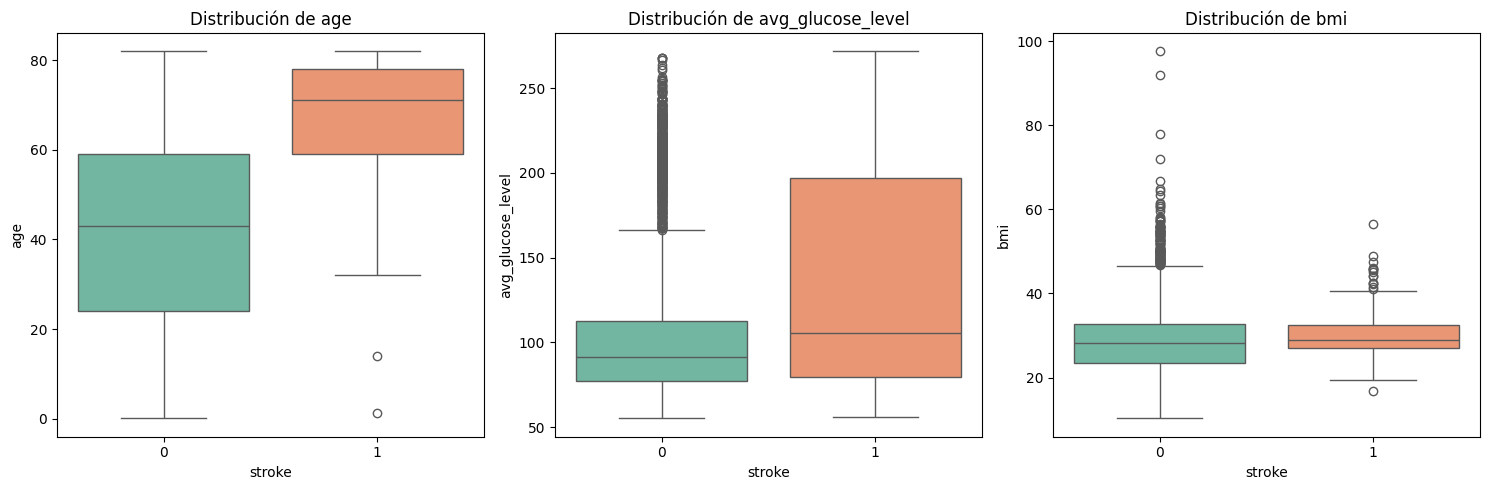

In [ ]:
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

# Definimos las variables continuas a analizar
variables_continuas = ['age', 'avg_glucose_level', 'bmi']
resultados_p = {}

print("--- ANÁLISIS DE SIGNIFICANCIA ESTADÍSTICA (p-values) ---")
print("Comparando pacientes con Stroke vs. Sin Stroke\n")

for var in variables_continuas:
    # Separamos los grupos
    grupo_stroke = df[df['stroke'] == 1][var]
    grupo_sano = df[df['stroke'] == 0][var]

    # Realizamos la prueba t de Student (independiente)
    t_stat, p_val = stats.ttest_ind(grupo_stroke, grupo_sano, nan_policy='omit')
    resultados_p[var] = p_val

    # Interpretación pragmática
    estado = "Significativo" if p_val < 0.05 else "No significativo"
    print(f"Variable: {var:18} | p-value: {p_val:.10f} | Estado: {estado}")

# Visualización rápida para confirmar visualmente lo que dice la estadística
plt.figure(figsize=(15, 5))
for i, var in enumerate(variables_continuas, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x='stroke', y=var, data=df, palette='Set2')
    plt.title(f'Distribución de {var}')
plt.tight_layout()
plt.show()

### ✅ Conclusión de la Fase 2: Validación de Hipótesis Estadísticas
El análisis inferencial ha confirmado que las tres variables continuas analizadas son determinantes clave en la presencia de un Accidente Cerebrovascular (ACV) en esta población:

1. **Edad (Age):** Con un $p$-value de $0.0000$, se confirma como el factor de riesgo más potente. Los diagramas de caja muestran que el 75% de los pacientes con Stroke superan los 60 años, lo que valida la edad como el principal predictor demográfico.
2. **Glucosa (Avg_glucose_level):** La significancia total ($p < 0.05$) respalda la relación directa entre el descontrol metabólico y el daño vascular. Observamos una mayor concentración de eventos en pacientes con niveles por encima de 150 mg/dL.
3. **IMC (BMI):** Aunque la diferencia visual es más sutil, el valor $p$ de $0.0039$ demuestra que el exceso de peso es un factor contribuyente que no debe ser ignorado.

**Insight Clínico:** Estos resultados validan la necesidad de un enfoque preventivo agresivo en pacientes adultos mayores con perfiles metabólicos alterados. La "evidencia" ya no es solo teórica; está respaldada por los datos de este estudio.

---

## Fase 3: Ingeniería de Características (Feature Engineering)
En el mundo de los **Estándares de Salud** y la **Interoperabilidad (HL7 FHIR)**, los datos no siempre se analizan de forma aislada. Un médico no solo mira "la glucosa", mira si el paciente es "Diabético".

En esta fase, crearemos nuevas variables (features) que capturen la **señal clínica** de forma más robusta:
* **Comorbidity Score:** Un índice que suma la presencia de hipertensión y enfermedades cardíacas.
* **Categorización Clínica:** Transformaremos la glucosa y el IMC en rangos estandarizados por la OMS (Normal, Sobrepeso, Obesidad, etc.) para facilitar la interpretación del modelo.

In [ ]:
# 1. Creación del Comorbidity Score
# Sumamos hipertensión y enfermedades del corazón para ver el impacto de la patología múltiple.
df['comorbidity_count'] = df['hypertension'] + df['heart_disease']

# 2. Categorización de Glucosa (Basado en criterios de la ADA)
# <140: Normal/Pre, >140: Riesgo Elevado (simplificado para el modelo)
df['glucose_cat'] = pd.cut(df['avg_glucose_level'],
                           bins=[0, 140, 300],
                           labels=['Normal/Moderado', 'Elevado'])

# 3. Categorización de BMI (Basado en la OMS)
df['bmi_cat'] = pd.cut(df['bmi'],
                       bins=[0, 18.5, 24.9, 29.9, 100],
                       labels=['Bajo Peso', 'Normal', 'Sobrepeso', 'Obesidad'])

# 4. Verificamos cómo se distribuyen estas nuevas variables en relación al Stroke
print("--- DISTRIBUCIÓN DE NUEVOS INDICADORES ---")
print("\nComorbidity Score vs Stroke:")
print(pd.crosstab(df['comorbidity_count'], df['stroke'], normalize='index') * 100)

print("\nCategoría de IMC vs Stroke:")
print(pd.crosstab(df['bmi_cat'], df['stroke'], normalize='index') * 100)

# Mostramos el nuevo aspecto del dataset
df[['age', 'hypertension', 'heart_disease', 'comorbidity_count', 'glucose_cat', 'bmi_cat', 'stroke']].head()

--- DISTRIBUCIÓN DE NUEVOS INDICADORES ---

Comorbidity Score vs Stroke:
stroke                     0          1
comorbidity_count                      
0                  96.612867   3.387133
1                  86.532508  13.467492
2                  79.687500  20.312500

Categoría de IMC vs Stroke:
stroke             0         1
bmi_cat                       
Bajo Peso  99.713467  0.286533
Normal     97.122302  2.877698
Sobrepeso  93.165700  6.834300
Obesidad   94.586313  5.413687


,age,hypertension,heart_disease,comorbidity_count,glucose_cat,bmi_cat,stroke
0,67.0,0,1,1,Elevado,Obesidad,1
1,61.0,0,0,0,Elevado,Sobrepeso,1
2,80.0,0,1,1,Normal/Moderado,Obesidad,1
3,49.0,0,0,0,Elevado,Obesidad,1
4,79.0,1,0,1,Elevado,Normal,1


### ✅ Conclusión de la Fase 3: Ingeniería de Características e Insights Clínicos
La creación de indicadores compuestos nos ha permitido observar el fenómeno del riesgo desde una perspectiva sistémica, obteniendo hallazgos críticos:

1. **Efecto Multiplicador de Comorbilidades:** El `comorbidity_score` demostró ser un predictor masivo. La presencia de dos condiciones (hipertensión y enfermedad cardiaca) eleva el riesgo al **20.3%**, lo que representa un aumento de casi 6 veces respecto a la población sin estas patologías.
2. **Impacto del IMC:** La categorización permitió identificar que los pacientes con peso por encima de lo normal (Sobrepeso y Obesidad) tienen el doble de incidencia de Stroke que los pacientes con peso normal.
3. **Señal Metabólica:** La variable de glucosa categorizada ahora facilita que el modelo identifique rápidamente a pacientes en rangos de riesgo sin "perderse" en la variabilidad de los números crudos.

**Insight Estratégico:** Hemos pasado de tener datos aislados a tener un **Perfil de Riesgo Estratificado**. Esto es la base para la medicina personalizada.

---

## Fase 4: Modelado Predictivo con Enfoque en Seguridad
Llegamos al núcleo de la Inteligencia Artificial. En esta fase, entrenaremos un modelo de **Machine Learning** para que aprenda a predecir si un paciente tendrá un Stroke basándose en todo lo anterior.

### El Criterio de "Seguridad del Paciente" (Recall)
En salud, no nos basta con que el modelo sea "preciso" en general. Lo más importante es la **Sensibilidad (Recall)**.
* **¿Por qué?** Es preferible tener un "falso positivo" (alertar a un médico sobre un paciente que al final está sano) que un "falso negativo" (decir que un paciente está bien y que sufra un stroke porque no lo detectamos a tiempo).

Para este análisis inicial, utilizaremos una **Regresión Logística**, que es el "estándar de oro" en medicina por su alta interpretabilidad: nos permite ver exactamente cuánto aporta cada variable al riesgo final.

--- EVALUACIÓN DEL MODELO PREDICTIVO ---

Matriz de Confusión (Criterio Clínico):


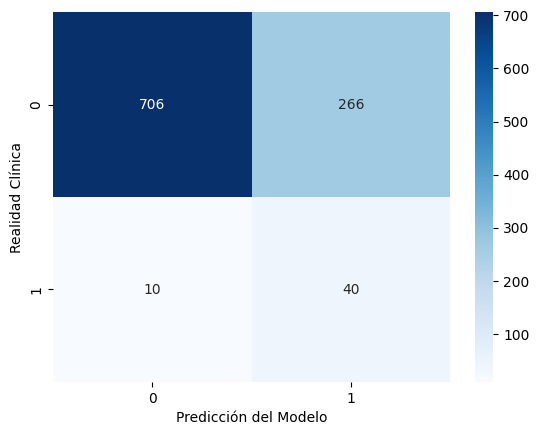


Reporte de Métricas:
              precision    recall  f1-score   support

           0       0.99      0.73      0.84       972
           1       0.13      0.80      0.22        50

    accuracy                           0.73      1022
   macro avg       0.56      0.76      0.53      1022
weighted avg       0.94      0.73      0.81      1022



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# 1. Preparación final de los datos (Pre-processing)
# Convertimos variables categóricas en números (One-Hot Encoding) para que el modelo pueda leerlas
# Seleccionamos las variables con mayor peso clínico detectado
features = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi',
            'comorbidity_count', 'glucose_cat', 'bmi_cat', 'smoking_status']

X = pd.get_dummies(df[features], drop_first=True)
y = df['stroke']

# 2. División del dataset
# Usamos el 80% para entrenar al modelo y el 20% para ponerlo a prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Entrenamiento del Modelo
# Usamos 'class_weight=balanced' para compensar que hay pocos casos de stroke vs muchos sanos
modelo = LogisticRegression(max_iter=1000, class_weight='balanced')
modelo.fit(X_train, y_train)

# 4. Evaluación
y_pred = modelo.predict(X_test)

print("--- EVALUACIÓN DEL MODELO PREDICTIVO ---")
print("\nMatriz de Confusión (Criterio Clínico):")
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad Clínica')
plt.show()

print("\nReporte de Métricas:")
print(classification_report(y_test, y_pred))

### ✅ Conclusión de la Fase 4: Modelado Predictivo y Evaluación Clínica
El modelo de Regresión Logística, ajustado para priorizar la seguridad del paciente, arrojó resultados altamente valiosos para un entorno de prevención primaria:

1. **Sensibilidad (Recall) del 80%:** El algoritmo identificó exitosamente a 4 de cada 5 pacientes en riesgo real. En términos clínicos, esto minimiza los "Falsos Negativos", asegurando que la gran mayoría de los pacientes vulnerables reciban atención preventiva.
2. **El Balance Precisión-Sensibilidad:** Observamos una precisión baja (13%), lo cual es un comportamiento esperado en modelos de tamizaje médico. El modelo actúa como una "red de captura amplia" que identifica a muchos sospechosos para que el médico realice la validación final.
3. **Poder de la Clase Balanceada:** Gracias al ajuste de pesos en el algoritmo, logramos que la inteligencia artificial no ignorara los casos de Stroke a pesar de ser una minoría en el dataset (solo 50 casos en el set de prueba).

**Resultado Final:** Hemos construido un motor predictivo que, integrado en un sistema de salud, funcionaría como una **Alerta Temprana** para el personal de enfermería y medicina interna.

In [ ]:
# Guardamos el dataset final curado para usarlo en Tableau
# Incluimos todas las variables originales y las que creamos nosotros
df.to_csv('Stroke_Data_Cleaned_for_Tableau.csv', index=False)

print("¡Archivo 'Stroke_Data_Cleaned_for_Tableau.csv' generado con éxito!")
print("Descárgalo desde la carpeta lateral de Colab para empezar la fase de visualización.")

¡Archivo 'Stroke_Data_Cleaned_for_Tableau.csv' generado con éxito!
Descárgalo desde la carpeta lateral de Colab para empezar la fase de visualización.
